# Lab 1: Wstęp do DICOM - Warsztaty Praktyczne
Ten notatnik zawiera część teoretyczną, przykłady oraz **zestaw zadań samodzielnych** do wykonania podczas pierwszych zajęć z Cyfrowego przetwarzania obrazów medycznych.

In [2]:
# Importujemy niezbędne biblioteki
import pydicom
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (8, 8)

## Część 1: Wczytanie pliku i podstawowe metadane

In [5]:
# Pobranie pliku testowego i wczytanie
from pydicom.data import get_testdata_files
filename = get_testdata_files("CT_small.dcm")[0]
ds = pydicom.dcmread(filename)

print(f"ID Pacjenta: {ds.PatientID}")
print(f"Modalność: {ds.Modality}")
print(f"Rozmiar macierzy: {ds.Rows} x {ds.Columns}")

ID Pacjenta: 1CT1
Modalność: CT
Rozmiar macierzy: 128 x 128


## Część 2: Wizualizacja macierzy pikseli

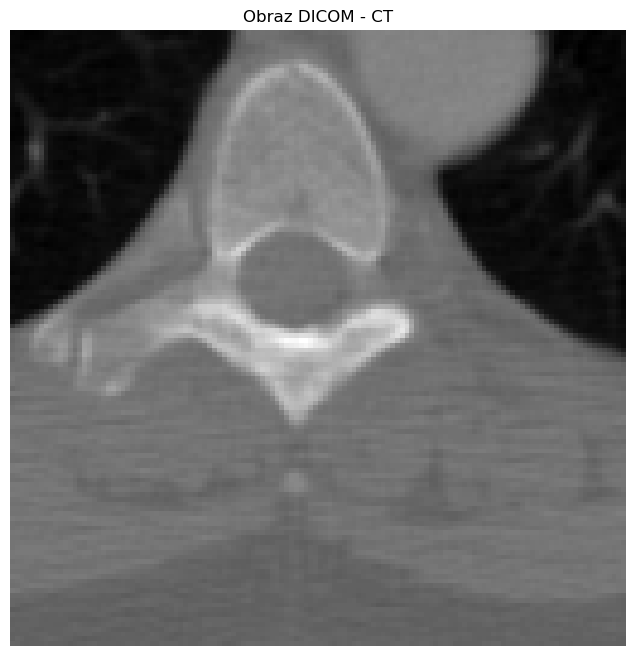

In [8]:
image_matrix = ds.pixel_array

plt.imshow(image_matrix, cmap='gray')
plt.title(f"Obraz DICOM - {ds.Modality}")
plt.axis('off')
plt.show()

--- 
# ZADANIA SAMODZIELNE DLA STUDENTÓW

### Zadanie 1: Eksploracja dodatkowych tagów
Wypisz w konsoli:
1. Nazwę producenta sprzętu (Tag: `Manufacturer`)
2. Napięcie lampy rentgenowskiej (Tag: `KVP`)

In [12]:
# Miejsce na Twój kod (Zadanie 1):
print(ds.get('Manufacturer', 'Brak'))
print(ds.get('KVP', 'Brak'))

GE MEDICAL SYSTEMS
120


### Zadanie 2: Fizyczne wymiary obrazu (Field of View)
Na podstawie tagów `Rows`, `Columns` oraz `PixelSpacing` oblicz fizyczny rozmiar tego zdjęcia w milimetrach dla osi X i Y.
Wydrukuj wynik w formacie np. *Fizyczny rozmiar obrazu: X mm x Y mm*.

In [25]:
# Miejsce na Twój kod (Zadanie 2):
spacing_y, spacing_x = ds.PixelSpacing
fov_y = ds.Rows * spacing_y
fov_x = ds.Columns * spacing_x
print(f"Fizyczny rozmiar obrazu (FOV): {fov_x:.1f} mm x {fov_y:.1f} mm")

Fizyczny rozmiar obrazu (FOV): 84.7 mm x 84.7 mm


### Zadanie 3: Wycinanie Regionu Zainteresowania (ROI)
Za pomocą indeksowania macierzy NumPy (`slicing`), stwórz nową zmienną zawierającą tylko centralny wycinek obrazu o wymiarach 50x50 pikseli.
Wyświetl ten wycinek za pomocą `matplotlib` w skali szarości.

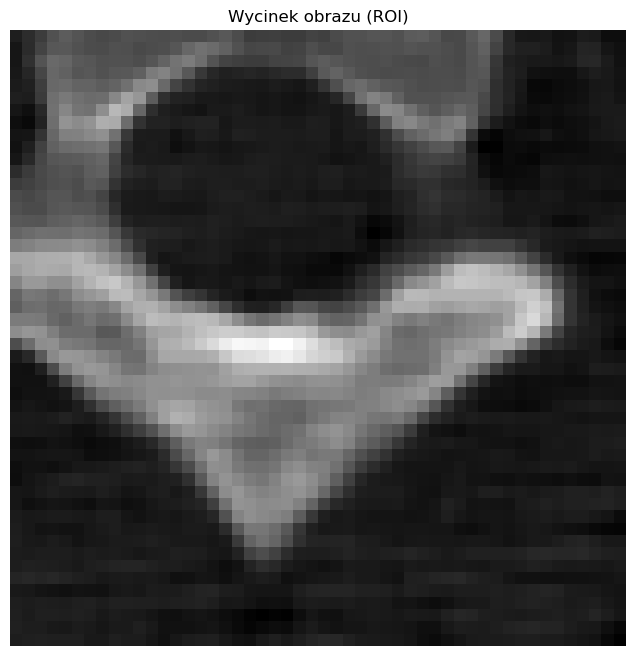

In [47]:
# Miejsce na Twój kod (Zadanie 3):
center_y, center_x = ds.Rows//2, ds.Columns//2
roi = image_matrix[center_y-25:center_y+25, center_x-25:center_x+25]
plt.imshow(roi, 'gray')
plt.title('Wycinek obrazu (ROI)')
plt.axis('off')
plt.show()

### Zadanie 4: Podstawy anonimizacji
1. Zmień `PatientID` na wartość `"ANONIMOWY_001"`.
2. Zmień nazwisko pacjenta na `"Ukryte"`.
3. Zapisz zmodyfikowany plik na dysku pod nazwą `"zanonimizowany_test.dcm"` używając metody `ds.save_as(...)`.

In [55]:
# Miejsce na Twój kod (Zadanie 4):
ds.PatientID = "ANONIMOWY_001"
ds.PatientName = "Ukryte" # Pydicom automatycznie przekonwertuje string na typ PersonName
ds.save_as("moj_zanonimizowany_plik.dcm")
print("Zapisano pomyślnie!")

Zapisano pomyślnie!


### Zadanie 5: Proste sterowanie kontrastem (Okienkowanie manualne)
Wyświetl obraz `image_matrix` ponownie, ale użyj argumentów `vmin` oraz `vmax` w funkcji `plt.imshow(..., vmin=..., vmax=...)`.
Poeksperymentuj z tymi wartościami tak, aby jak najlepiej uwidocznić strukturę kości lub tkanek miękkich.

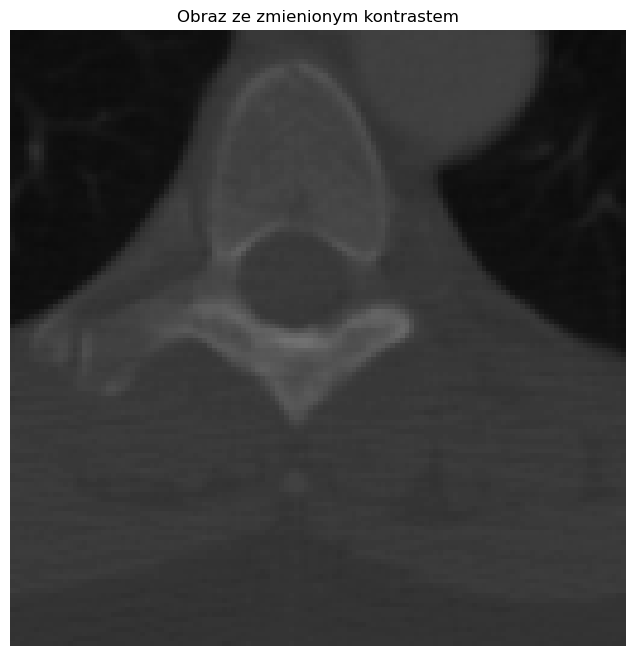

In [69]:
# Miejsce na Twój kod (Zadanie 5):
plt.imshow(image_matrix, cmap='gray', vmin=-100, vmax=5000) # Wartości przykładowe
plt.title("Obraz ze zmienionym kontrastem")
plt.axis('off')
plt.show()